In [ ]:
import numpy as np
import numpy as np
from jax import config
import sax
from simphony.libraries import siepic, sipann
import jax.numpy as jnp
import matplotlib.pyplot as plt
from functools import partial

# we are on notebook, so enable interactive mode for plotting
plt.ion()

config.update("jax_enable_x64", True)

/home/juanjo/Projects/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/comp.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
I0000 00:00:1780656268.953829   36645 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780656270.651484   36645 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


INFO:tensorflow:Restoring parameters from /home/juanjo/Projects/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/ANN/TIGHT_ANGLE_GAP/model
INFO:tensorflow:Restoring parameters from /home/juanjo/Projects/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/ANN/TIGHT_ANGLE_STRAIGHT/model


/home/juanjo/Projects/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/import_nn.py:125: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict_ = pickle.load(file)
E0000 00:00:1780656271.532078   36645 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


INFO:tensorflow:Restoring parameters from /home/juanjo/Projects/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/ANN/TIGHT_ANGLE_BENT_RAND/model


/home/juanjo/Projects/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/import_nn.py:286: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict_ = pickle.load(file)


In [32]:
# 3 add muxes and 3 drop filters


netlist = {
    "instances": {
        "ring_m1_up": "half_ring",
        "ring_m1_down": "half_ring",
        "ring_m2_up": "half_ring",
        "ring_m2_down": "half_ring",
        # "ring_m3_up": "half_ring",
        # "ring_m3_down": "half_ring",
        "ring_d1_up": "half_ring",
        "ring_d1_down": "half_ring",
        "ring_d2_up": "half_ring",
        "ring_d2_down": "half_ring",
        # "ring_d3_up": "half_ring",
        # "ring_d3_down": "half_ring",
        "wg1": "waveguide",
        "wg2": "waveguide",
        "wg3": "waveguide",
    },
    "connections": {
        "ring_m1_up,o1": "ring_m1_down,o3",
        "ring_m1_down,o1": "ring_m1_up,o3",
        "ring_m2_up,o1": "ring_m2_down,o3",
        "ring_m2_down,o1": "ring_m2_up,o3",
        # "ring_m3_up,o1": "ring_m3_down,o3",
        # "ring_m3_down,o1": "ring_m3_up,o3",
        "ring_d1_up,o1": "ring_d1_down,o3",
        "ring_d1_down,o1": "ring_d1_up,o3",
        "ring_d2_up,o1": "ring_d2_down,o3",
        "ring_d2_down,o1": "ring_d2_up,o3",
        # "ring_d3_up,o1": "ring_d3_down,o3",
        # "ring_d3_down,o1": "ring_d3_up,o3",
        "wg1,o0": "ring_m1_up,o2",
        "wg1,o1": "ring_m2_up,o0",
        "wg2,o0": "ring_m2_up,o2",
        "wg2,o1": "ring_d1_up,o0",
        "wg3,o0": "ring_d1_up,o2",
        "wg3,o1": "ring_d2_up,o0",
    },
    "ports": {
        "laser_in": "ring_m1_up,o0",
        "out_1": "ring_d1_down,o2", # drop port of drop filter 1
        "out_2": "ring_d2_down,o2", # drop port of drop filter 2
        "out_remaining": "ring_d2_up,o2", # through port of drop filter 2
    }
}

models = {
    "half_ring": partial(sipann.half_ring, width=500, thickness=220, gap=100),
    "waveguide": siepic.waveguide,
}

params = {
    "ring_m1_up": {"radius": 5},
    "ring_m1_down": {"radius": 5},
    "ring_m2_up": {"radius": 7},
    "ring_m2_down": {"radius": 7},
    # "ring_m3_up": {"radius": 9},
    # "ring_m3_down": {"radius": 9},
    "ring_d1_up": {"radius": 5},
    "ring_d1_down": {"radius": 5},
    "ring_d2_up": {"radius": 7},
    "ring_d2_down": {"radius": 7},
    # "ring_d3_up": {"r": 9},
    # "ring_d3_down": {"r": 9},
    "wg1": {"length": 10},
    "wg2": {"length": 30},
    "wg3": {"length": 10},
}

# create the circuit
circuit, info = sax.circuit(
    netlist=netlist,
    models=models
)

In [33]:
wls = np.linspace(1.55, 1.6, 100)
S = circuit(wl=wls, **params)

In [34]:
# Power
mag = jnp.abs(S["out_1","laser_in"])**2
# Loss
loss = 10*jnp.log10(mag)
# Phase
phase = jnp.angle(S["out_1","laser_in"])

Text(0.5, 1.0, 'Power at Drop Port 1')

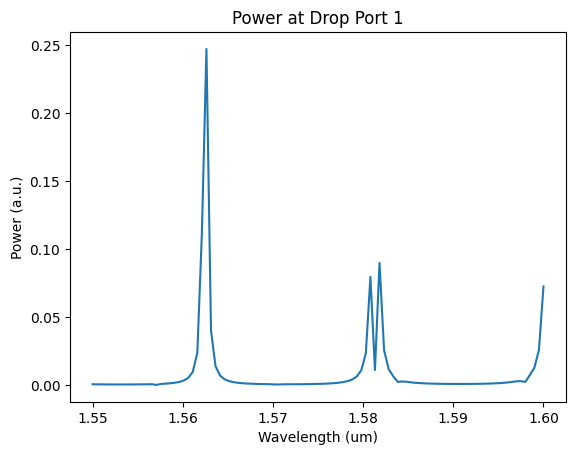

In [35]:
# Plot Power
plt.figure()
plt.plot(wls, mag)
plt.xlabel("Wavelength (um)")
plt.ylabel("Power (a.u.)")
plt.title("Power at Drop Port 1")

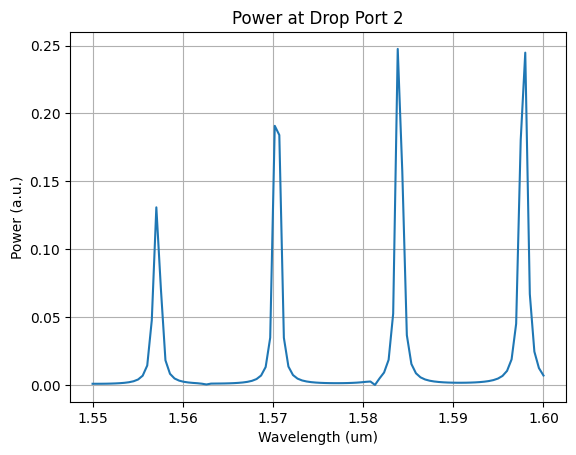

In [19]:
mag_2 = jnp.abs(S["out_2","laser_in"])**2
plt.figure()
plt.plot(wls, mag_2)
plt.xlabel("Wavelength (um)")
plt.ylabel("Power (a.u.)")
plt.title("Power at Drop Port 2")
plt.grid()

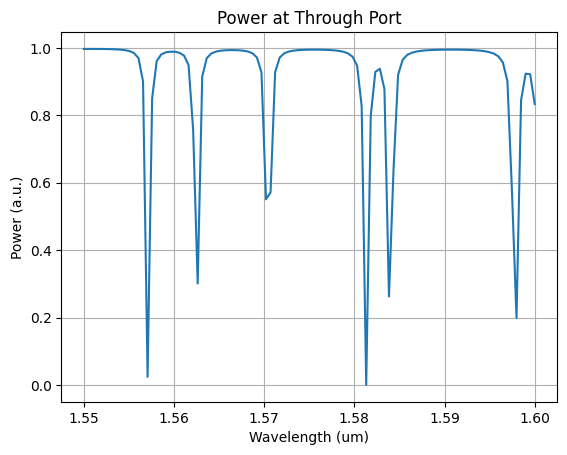

In [20]:
# remaining power at through port
mag_remaining = jnp.abs(S["out_remaining","laser_in"])**2
plt.figure()
plt.plot(wls, mag_remaining)
plt.xlabel("Wavelength (um)")
plt.ylabel("Power (a.u.)")
plt.title("Power at Through Port")
plt.grid()

In [5]:
d = {
    "name": "Juan Jo",
    "data": {
        "age": 30,
        "city": "Madrid"
    }
}

def foo(log_n, s, **params):
    print(log_n, "--",s)
    if "name" in params:
        print("Name:", params["name"])
    if "data" in params:
        print("Data:", params["data"])

foo(1, "hello", **d)

1 -- hello
Name: Juan Jo
Data: {'age': 30, 'city': 'Madrid'}


In [2]:
# 3 add muxes and 3 drop filters


netlist = {
    "instances": {
        "ring_m1_up": "half_ring",
        "ring_m1_down": "half_ring",
        "ring_a1_up": "half_ring",
        "ring_a1_down": "half_ring",
        "ring_m2_up": "half_ring",
        "ring_m2_down": "half_ring",
        "ring_a2_up": "half_ring",
        "ring_a2_down": "half_ring",
        # "ring_m3_up": "half_ring",
        # "ring_m3_down": "half_ring",
        # "ring_d1_up": "half_ring",
        # "ring_d1_down": "half_ring",
        # "ring_d2_up": "half_ring",
        # "ring_d2_down": "half_ring",
        # "ring_d3_up": "half_ring",
        # "ring_d3_down": "half_ring",
        "wg1": "waveguide",
        "wg2": "waveguide",
        "wg3": "waveguide",
    },
    "connections": {
        "ring_m1_up,o1": "ring_m1_down,o3",
        "ring_m1_down,o1": "ring_m1_up,o3",
        "ring_a1_up,o1": "ring_a1_down,o3",
        "ring_a1_down,o1": "ring_a1_up,o3",
        "ring_m1_down,o2": "wg1,o0",
        "ring_a1_up,o2": "wg1,o1",

        "ring_m2_up,o1": "ring_m2_down,o3",
        "ring_m2_down,o1": "ring_m2_up,o3",
        "ring_a2_up,o1": "ring_a2_down,o3",
        "ring_a2_down,o1": "ring_a2_up,o3",
        "ring_m2_down,o2": "wg2,o0",
        "ring_a2_up,o2": "wg2,o1",
        
        "ring_a1_down,o0": "wg3,o0",
        "ring_a2_down,o2": "wg3,o1",
        # "ring_m3_up,o1": "ring_m3_down,o3",
        # "ring_m3_down,o1": "ring_m3_up,o3",
        # "ring_d1_up,o1": "ring_d1_down,o3",
        # "ring_d1_down,o1": "ring_d1_up,o3",
        # "ring_d2_up,o1": "ring_d2_down,o3",
        # "ring_d2_down,o1": "ring_d2_up,o3",
        # "ring_d3_up,o1": "ring_d3_down,o3",
        # "ring_d3_down,o1": "ring_d3_up,o3",
        # "wg1,o0": "ring_m1_up,o2",
        # "wg1,o1": "ring_m2_up,o0",
        # "wg2,o0": "ring_m2_up,o2",
        # "wg2,o1": "ring_d1_up,o0",
        # "wg3,o0": "ring_d1_up,o2",
        # "wg3,o1": "ring_d2_up,o0",
        # "ring_m1_down,o2": "ring_a1_up,o2",
    },
    "ports": {
        "laser_in1": "ring_m1_up,o0",
        "laser_in2": "ring_m2_up,o0",
        "bus": "ring_a2_down,o0", # drop port of drop filter 1
    }
}

models = {
    "half_ring": partial(sipann.half_ring, width=500, thickness=220, gap=100),
    "waveguide": siepic.waveguide,
}

params = {
    "ring_m1_up": {"radius": 5},
    "ring_m1_down": {"radius": 5},
    "ring_a1_up": {"radius": 5},
    "ring_a1_down": {"radius": 5},
    "ring_m2_up": {"radius": 8},
    "ring_m2_down": {"radius": 8},
    "ring_a2_up": {"radius": 8},
    "ring_a2_down": {"radius": 8},
    "wg1": {"length": 10},
    "wg2": {"length": 10},
    "wg3": {"length": 20},
    # "ring_m2_up": {"radius": 7},
    # "ring_m2_down": {"radius": 7},
    # "ring_m3_up": {"radius": 9},
    # "ring_m3_down": {"radius": 9},
    # "ring_d1_up": {"radius": 5},
    # "ring_d1_down": {"radius": 5},
    # "ring_d2_up": {"radius": 7},
    # "ring_d2_down": {"radius": 7},
    # "ring_d3_up": {"r": 9},
    # "ring_d3_down": {"r": 9},
    # "wg1": {"length": 10},
    # "wg2": {"length": 30},
    # "wg3": {"length": 10},
}

# create the circuit
circuit, info = sax.circuit(
    netlist=netlist,
    models=models
)



In [4]:
%matplotlib widget

FloatSlider(value=5.0, description='r1 (um):', max=5.5, min=4.5, step=0.05)

FloatSlider(value=8.0, description='r2 (um):', max=8.5, min=7.5, step=0.05)

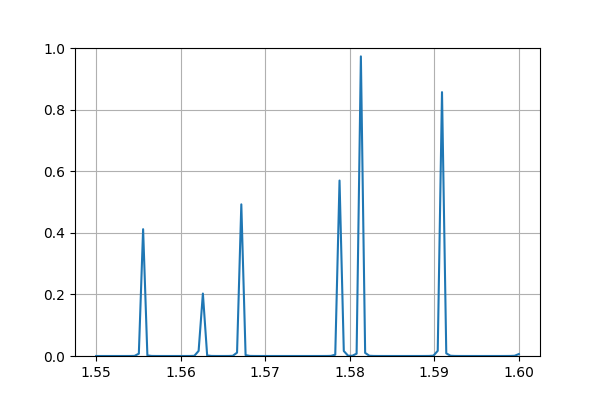

In [5]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

wls = np.linspace(1.55, 1.6, 100)
x = wls
S = circuit(wl=wls, **params)
power_bus = jnp.abs(S["bus","laser_in1"])**2 + jnp.abs(S["bus","laser_in2"])**2

fig, ax = plt.subplots(figsize=(6, 4))
line, = ax.plot(wls, power_bus)

# ax.set_xlim(-1, 1)
ax.set_ylim(0, 1)
ax.grid(True)

slider = widgets.FloatSlider(
    value=5.0,
    min=4.5,
    max=5.5,
    step=0.05,
    description="r1 (um):",
    continuous_update=True
)

slider_r2 = widgets.FloatSlider(
    value=8.0,
    min=7.5,
    max=8.5,
    step=0.05,
    description="r2 (um):",
    continuous_update=True
)

def update(change):
    name = change["owner"].description
    if "r1" in name:
        r1 = change["new"]
        params["ring_m1_up"]["radius"] = r1
        params["ring_m1_down"]["radius"] = r1
    elif "r2" in name:
        r2 = change["new"]
        params["ring_m2_up"]["radius"] = r2
        params["ring_m2_down"]["radius"] = r2
    S = circuit(wl=wls, **params)
    power_bus = jnp.abs(S["bus","laser_in1"])**2 + jnp.abs(S["bus","laser_in2"])**2
    line.set_ydata(power_bus)
    ax.set_title(f"Power at Bus Port")
    fig.canvas.draw_idle()

slider.observe(update, names="value")
slider_r2.observe(update, names="value")

display(slider)
display(slider_r2)
plt.show()